In [1]:
import numpy as np
import pandas as pd
import graphviz
import lingam
from lingam.utils import make_dot

print([np.__version__, pd.__version__, graphviz.__version__, lingam.__version__])

np.set_printoptions(precision=3, suppress=True)
np.random.seed(100)

csv='LiNGAM_latest3'
csv='nonlinear_LiNGAM_latest3a'
csv='nonlinear_LiNGAM_latest3b'
csv='nonlinear_LiNGAM_latest3c'
import time



def Causal_discovery_test( csv ):
    csv_data = pd.read_csv('../Causal_discovery-Experiment-main/Causal_discovery-Experiment-main/Causal_Search_Experiment/'+csv+'.csv')
    #print(csv_data)
    
    X = pd.DataFrame(csv_data, columns=["x1", "x2", "x3", "x4", "x5","f1","f2"])
    model = lingam.ICALiNGAM()
    start = time.perf_counter()
    model.fit(X)
    end = time.perf_counter()
    print('ICALiNGAM_'+csv)
    print((end-start)/60)
    
    dot1 = make_dot(model.adjacency_matrix_, labels=['x1','x2','x3','x4','x5','f1','f2'])
    
    dot1
    dot1.graph_attr.update({
        'label': 'ICALiNGAM',
        'labelloc': 't', 
        'fontsize': '20',
        'dpi':'200' 
    })
    dot1.render('ICALiNGAM_'+csv, format='png')
    
    X=X[['x1','x2','x3','x4','x5']]
    X.head()
    model = lingam.ICALiNGAM()
    start = time.perf_counter()
    model.fit(X)
    end = time.perf_counter()
    print('ICALiNGAM(f1,f2 delete)_'+csv)
    print((end-start)/60)
    dot2 = make_dot(model.adjacency_matrix_, labels=['x1','x2','x3','x4','x5'])
    
    dot2.graph_attr.update({
        'label': 'ICALiNGAM(f1,f2 delete)', 
        'labelloc': 't',                  
        'fontsize': '20',
        'dpi':'200'                  
    })
    dot2.render('ICALiNGAM(f1,f2 delete)_'+csv, format='png')
    dot2

    
    model = lingam.RCD()
    start = time.perf_counter()
    model.fit(X)
    end = time.perf_counter()
    print('RCD(f1,f2 delete)_'+csv)
    print((end-start)/60)
    dot3 = make_dot(model.adjacency_matrix_, labels=['x1','x2','x3','x4','x5'])
    
    dot3.graph_attr.update({
        'label': 'RCD(f1,f2 delete)',  
        'labelloc': 't',                  
        'fontsize': '20',
        'dpi':'200'                 
    })
    dot3.render('RCD(f1,f2 delete)_'+csv, format='png')    
    dot3

    model = lingam.BottomUpParceLiNGAM()
    start = time.perf_counter()
    model.fit(X)
    end = time.perf_counter()
    print('BottomUpParceLiNGAM(f1,f2 delete)_'+csv)
    print((end-start)/60)
    dot4 = make_dot(model.adjacency_matrix_, labels=['x1','x2','x3','x4','x5'])
    
    
    dot4.graph_attr.update({
        'label': 'BottomUpParceLiNGAM(f1,f2 delete)',  
        'labelloc': 't',                  
        'fontsize': '20',
        'dpi':'200'                  
    })
    dot4.render('BottomUpParceLiNGAM(f1,f2 delete)_'+csv, format='png')
    dot4

    model = lingam.CAMUV()
    start = time.perf_counter()
    model.fit(X)
    end = time.perf_counter()
    print('CAMUV(f1,f2 delete)_'+csv)
    print((end-start)/60)

    #model._adjacency_matrix = np.nan_to_num(model._adjacency_matrix, nan=-999)
    dot5 = make_dot(model._adjacency_matrix, labels=['x1','x2','x3','x4','x5'])
    
    
    dot5.graph_attr.update({
        'label': 'CAMUV(f1,f2 delete)',  
        'labelloc': 't',                  
        'fontsize': '20',
        'dpi':'200'                  
    })
    dot5.render('CAMUV(f1,f2 delete)_'+csv, format='png')
    dot5
    
    
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 5, figsize=(12*2*2*2, 6*2*2*2))
    
    ax[0].imshow( plt.imread('ICALiNGAM_'+csv+'.png'))
    ax[1].imshow( plt.imread('ICALiNGAM(f1,f2 delete)_'+csv+'.png'))
    ax[2].imshow( plt.imread('RCD(f1,f2 delete)_'+csv+'.png'))
    ax[3].imshow( plt.imread('BottomUpParceLiNGAM(f1,f2 delete)_'+csv+'.png'))
    ax[4].imshow( plt.imread('CAMUV(f1,f2 delete)_'+csv+'.png'))
    fig.tight_layout() 
    plt.savefig('Causal_discovery_'+csv+'.png', dpi=300)
    plt.tight_layout()
    plt.show()    

    

['1.26.4', '2.2.3', '0.20.3', '1.9.1']


In [ ]:
from __future__ import annotations

from typing import TypeAlias, Any
import numpy as np
from numpy.typing import NDArray

from train import AbPNLTrainer
from synthproblems import PostNonlinearNToOne, generate_samples
T: TypeAlias = NDArray[np.floating[Any]]

import pandas as pd
import graphviz
import lingam
from lingam.utils import make_dot

import time


def d_edit(a: T, b: T) -> Any:
    return np.logical_xor((a != 0), (b != 0)).sum()


def n_rev(a: T, b: T) -> Any:
    return ((a != 0) * (b != 0).T).sum()


def Causal_discovery_test2( csv ):
    csv_data = pd.read_csv('../Causal_discovery-Experiment-main/Causal_discovery-Experiment-main/Causal_Search_Experiment/'+csv+'.csv')
    #print(csv_data)
    
    X = pd.DataFrame(csv_data)
    model = lingam.ICALiNGAM()
    start = time.perf_counter()
    model.fit(X)
    end = time.perf_counter()
    print('ICALiNGAM_'+csv)
    print((end-start)/60)
    print(X.columns.values)
    dot1 = make_dot(model.adjacency_matrix_, labels=X.columns.to_list())
    
    dot1
    dot1.graph_attr.update({
        'label': 'ICALiNGAM',
        'labelloc': 't', 
        'fontsize': '20',
        'dpi':'200'
    })
    dot1.render('ICALiNGAM_'+csv, format='png')
    
    
    model = lingam.RCD()
    start = time.perf_counter()
    model.fit(X)
    end = time.perf_counter()
    print('RCD_'+csv)
    print((end-start)/60)
    dot3 = make_dot(model.adjacency_matrix_, labels=X.columns.to_list())
    
    dot3.graph_attr.update({
        'label': 'RCD',  
        'labelloc': 't',                  
        'fontsize': '20',
        'dpi':'200'                 
    })
    dot3.render('RCD_'+csv, format='png')    
    dot3

    model = lingam.BottomUpParceLiNGAM()
    start = time.perf_counter()
    model.fit(X)
    end = time.perf_counter()
    print('BottomUpParceLiNGAM_'+csv)
    print((end-start)/60)
    dot4 = make_dot(model.adjacency_matrix_, labels=X.columns.to_list())
    
    
    dot4.graph_attr.update({
        'label': 'BottomUpParceLiNGAM',  
        'labelloc': 't',                  
        'fontsize': '20'                  
    })
    dot4.render('BottomUpParceLiNGAM_'+csv, format='png')
    dot4

    model = lingam.CAMUV()
    start = time.perf_counter()
    model.fit(X)
    end = time.perf_counter()
    print('CAMUV_'+csv)
    print((end-start)/60)

    #model._adjacency_matrix = np.nan_to_num(model._adjacency_matrix, nan=-999)
    dot5 = make_dot(model._adjacency_matrix, labels=X.columns.to_list())
    
    
    dot5.graph_attr.update({
        'label': 'CAMUV',  
        'labelloc': 't',                  
        'fontsize': '20',
        'dpi':'200'                  
    })
    dot5.render('CAMUV_'+csv, format='png')
    dot5

    size = X.shape[0]
    X=X.astype(np.float32)
    k = int(0.7*size)
    x_train = X[:k].values
    x_test = X[k:].values
    
    x_train
    params = AbPNLTrainer.default_params
    params["logdir"] = "results/eg1"
    params["max_workers"] = 3
    #params["n_units"] = 16
    #params["batchsize"] = 64
    
    start = time.perf_counter()
    abpnl = AbPNLTrainer(params)    
    abpnl.doit(x_train, x_test)
    end = time.perf_counter()
    print('abpnl_'+csv)
    print((end-start)/60)
    
    co = abpnl.causal_order
    am = abpnl.adjacency_matrix
    dot6 = make_dot(am, labels=X.columns.to_list())
    dot6.graph_attr.update({
        'label': 'abpnl',  
        'labelloc': 't',                  
        'fontsize': '20',
        'dpi':'200'                  
    })
    dot6.render('abpnl_'+csv, format='png')
    dot6

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 5, figsize=(12*2*2*2, 6*2*2*2))
    
    ax[0].imshow( plt.imread('ICALiNGAM_'+csv+'.png'))
    ax[1].imshow( plt.imread('RCD_'+csv+'.png'))
    ax[2].imshow( plt.imread('BottomUpParceLiNGAM_'+csv+'.png'))
    ax[3].imshow( plt.imread('CAMUV_'+csv+'.png'))
    ax[4].imshow( plt.imread('abpnl_'+csv+'.png'))
    fig.tight_layout() 
    plt.savefig('Causal_discovery_'+csv+'.png', dpi=300)
    plt.tight_layout()
    plt.show()       

 

In [1]:
from __future__ import annotations

from typing import TypeAlias, Any
import numpy as np
from numpy.typing import NDArray

from train import AbPNLTrainer
from synthproblems import PostNonlinearNToOne, generate_samples
T: TypeAlias = NDArray[np.floating[Any]]

import pandas as pd
import graphviz
import lingam
from lingam.utils import make_dot

import time


def d_edit(a: T, b: T) -> Any:
    return np.logical_xor((a != 0), (b != 0)).sum()


def n_rev(a: T, b: T) -> Any:
    return ((a != 0) * (b != 0).T).sum()


def Causal_discovery_test3( csv, delitem ):
    csv_data = pd.read_csv('../Causal_discovery-Experiment-main/Causal_discovery-Experiment-main/Causal_Search_Experiment/'+csv+'.csv')
    #print(csv_data)


    X = pd.DataFrame(csv_data)

    labels=X.columns.to_list()
    for i in delitem:
        labels.remove(i)
    print(labels)

    X = pd.DataFrame(csv_data, columns=labels)    
    
    size = X.shape[0]
    X=X.astype(np.float32)
    k = int(0.7*size)
    x_train = X[:k].values
    x_test = X[k:].values
    
    x_train
    params = AbPNLTrainer.default_params
    params["logdir"] = "results/eg1"
    params["max_workers"] = 3
    #params["n_units"] = 16
    #params["batchsize"] = 64
    
    start = time.perf_counter()
    abpnl = AbPNLTrainer(params)    
    abpnl.doit(x_train, x_test)
    end = time.perf_counter()
    print('abpnl_'+csv)
    print((end-start)/60)
    
    co = abpnl.causal_order
    am = abpnl.adjacency_matrix
    dot6 = make_dot(am, labels=labels)
    dot6.graph_attr.update({
        'label': 'abpnl',  
        'labelloc': 't',                  
        'fontsize': '20',
        'dpi':'200'                  
    })
    if delitem==[] : dot6.render('abpnl_'+csv, format='png')
    if delitem!=[] : dot6.render('abpnl(delete_f1f2)_'+csv, format='png')
    
    dot6
   

ICALiNGAM_LiNGAM_latest3
0.0003295516672854622
ICALiNGAM(f1,f2 delete)_LiNGAM_latest3
0.00022955999981301526


C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: U

RCD(f1,f2 delete)_LiNGAM_latest3
4.411584648332791
BottomUpParceLiNGAM(f1,f2 delete)_LiNGAM_latest3
3.004066503333161
CAMUV(f1,f2 delete)_LiNGAM_latest3
5.371645298332441


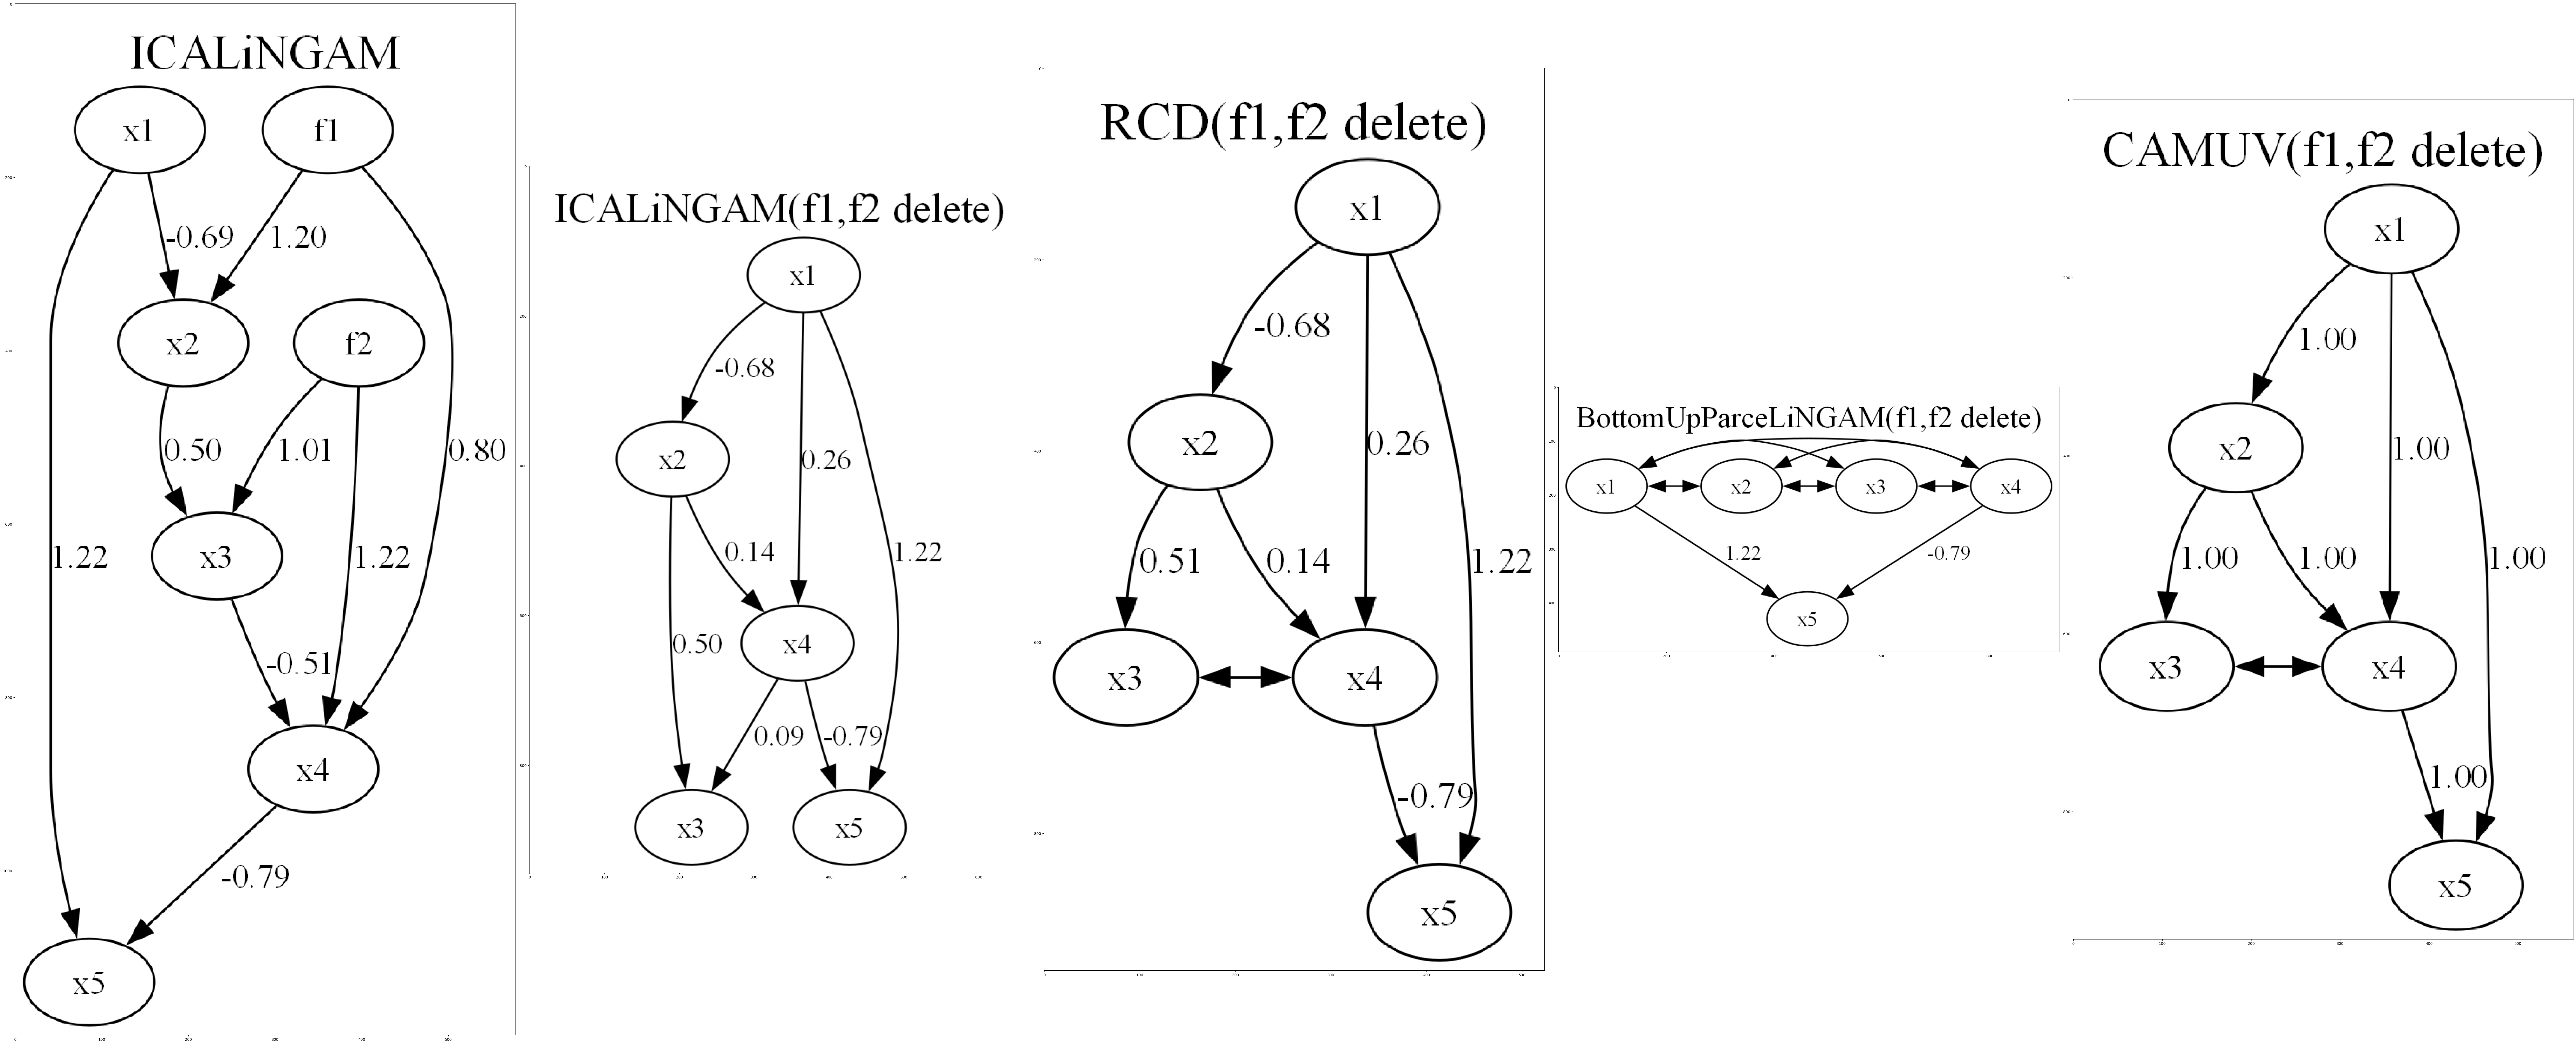

ICALiNGAM_nonlinear_LiNGAM_latest3a
0.00042998499896687765
ICALiNGAM(f1,f2 delete)_nonlinear_LiNGAM_latest3a
0.00041459500013540186


C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: U

RCD(f1,f2 delete)_nonlinear_LiNGAM_latest3a
1.5480115699989256
BottomUpParceLiNGAM(f1,f2 delete)_nonlinear_LiNGAM_latest3a
1.6488080933340825
CAMUV(f1,f2 delete)_nonlinear_LiNGAM_latest3a
5.717404008334658


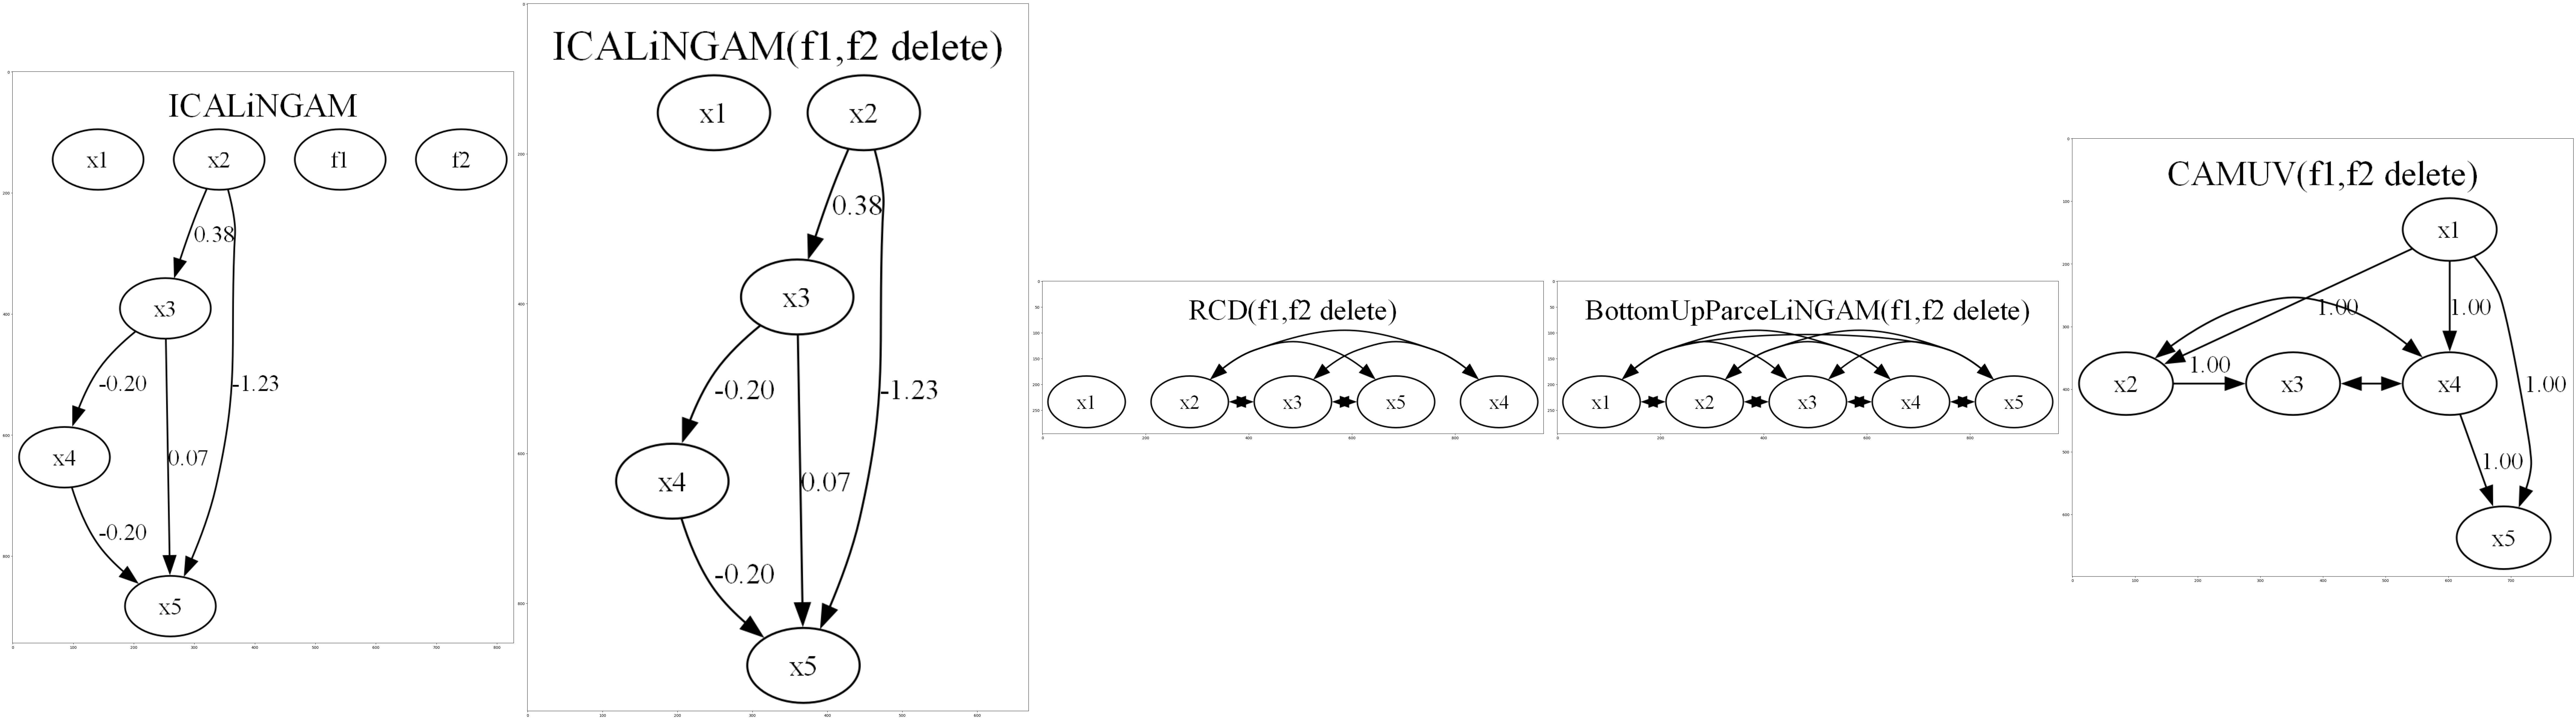

ICALiNGAM_nonlinear_LiNGAM_latest3b
0.00041016499938753743


C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


ICALiNGAM(f1,f2 delete)_nonlinear_LiNGAM_latest3b
0.006290421667896832


C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: U

RCD(f1,f2 delete)_nonlinear_LiNGAM_latest3b
2.513901111665958
BottomUpParceLiNGAM(f1,f2 delete)_nonlinear_LiNGAM_latest3b
1.1678495166668048
CAMUV(f1,f2 delete)_nonlinear_LiNGAM_latest3b
5.6684279516669145


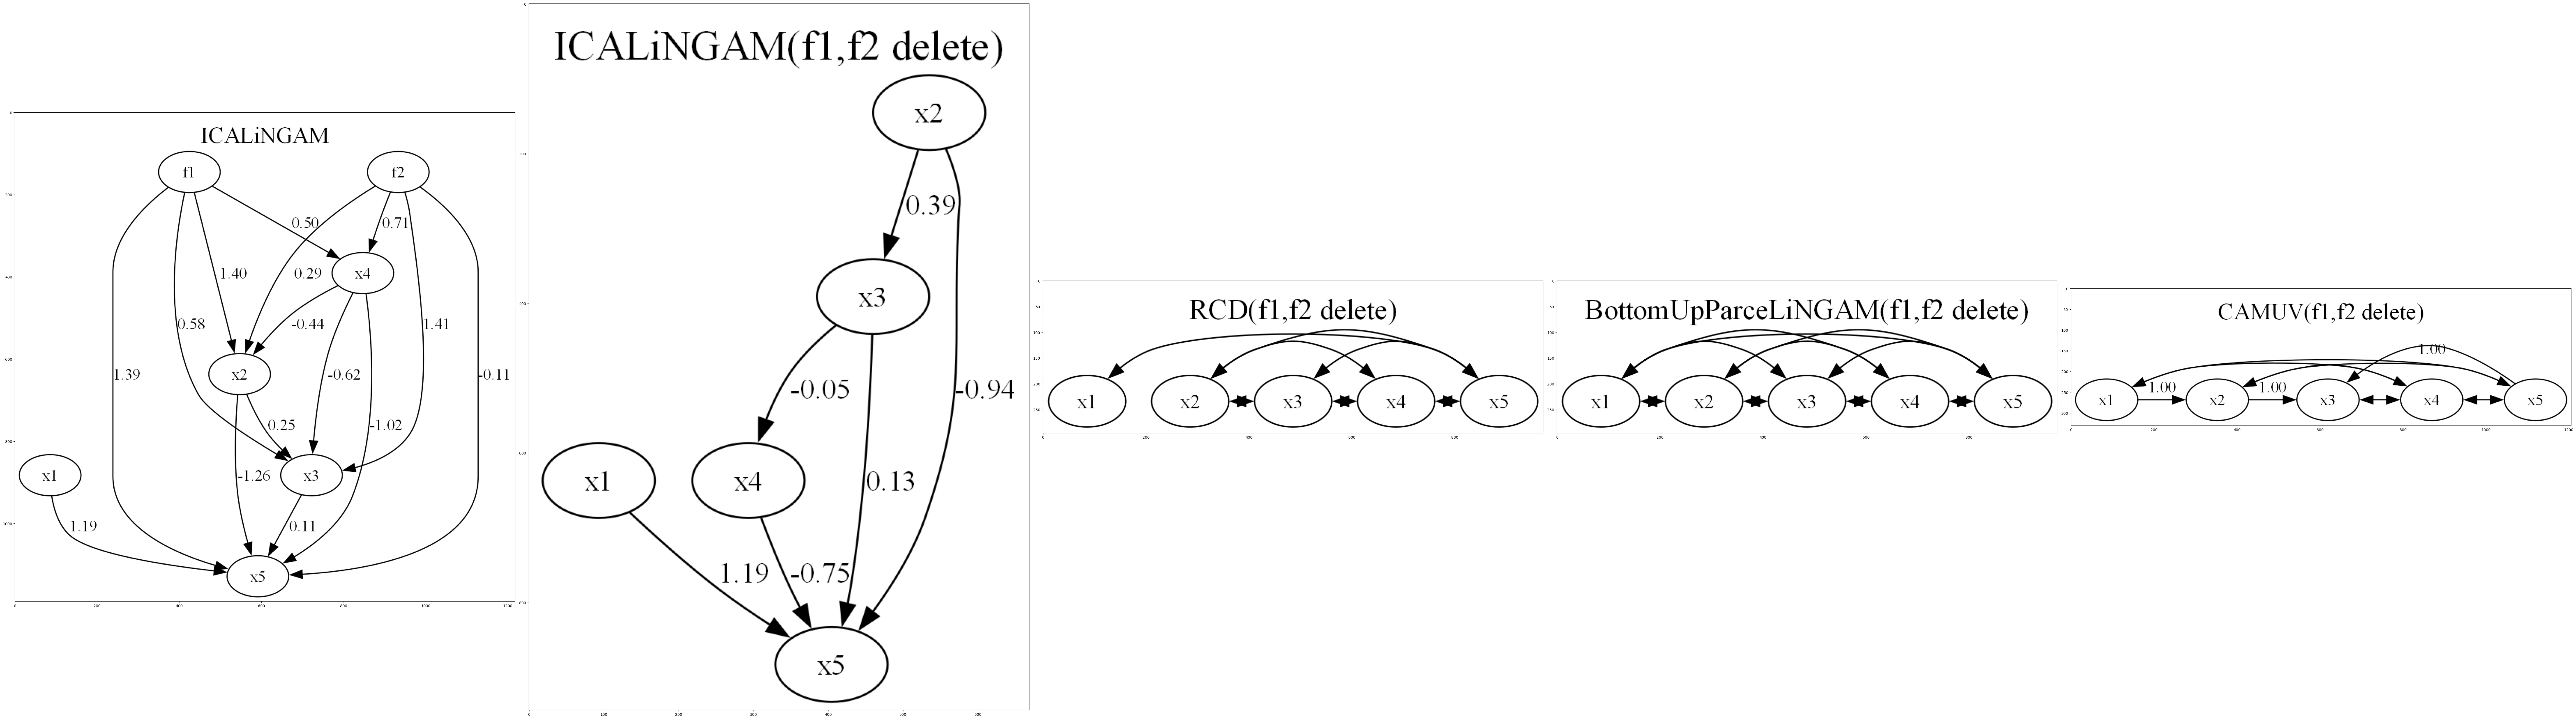

ICALiNGAM_nonlinear_LiNGAM_latest3c
0.0006082033331040293
ICALiNGAM(f1,f2 delete)_nonlinear_LiNGAM_latest3c
0.00048733999913868806


C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: U

RCD(f1,f2 delete)_nonlinear_LiNGAM_latest3c
6.032008646665296
BottomUpParceLiNGAM(f1,f2 delete)_nonlinear_LiNGAM_latest3c
3.7251004700005677
CAMUV(f1,f2 delete)_nonlinear_LiNGAM_latest3c
9.006416546667849


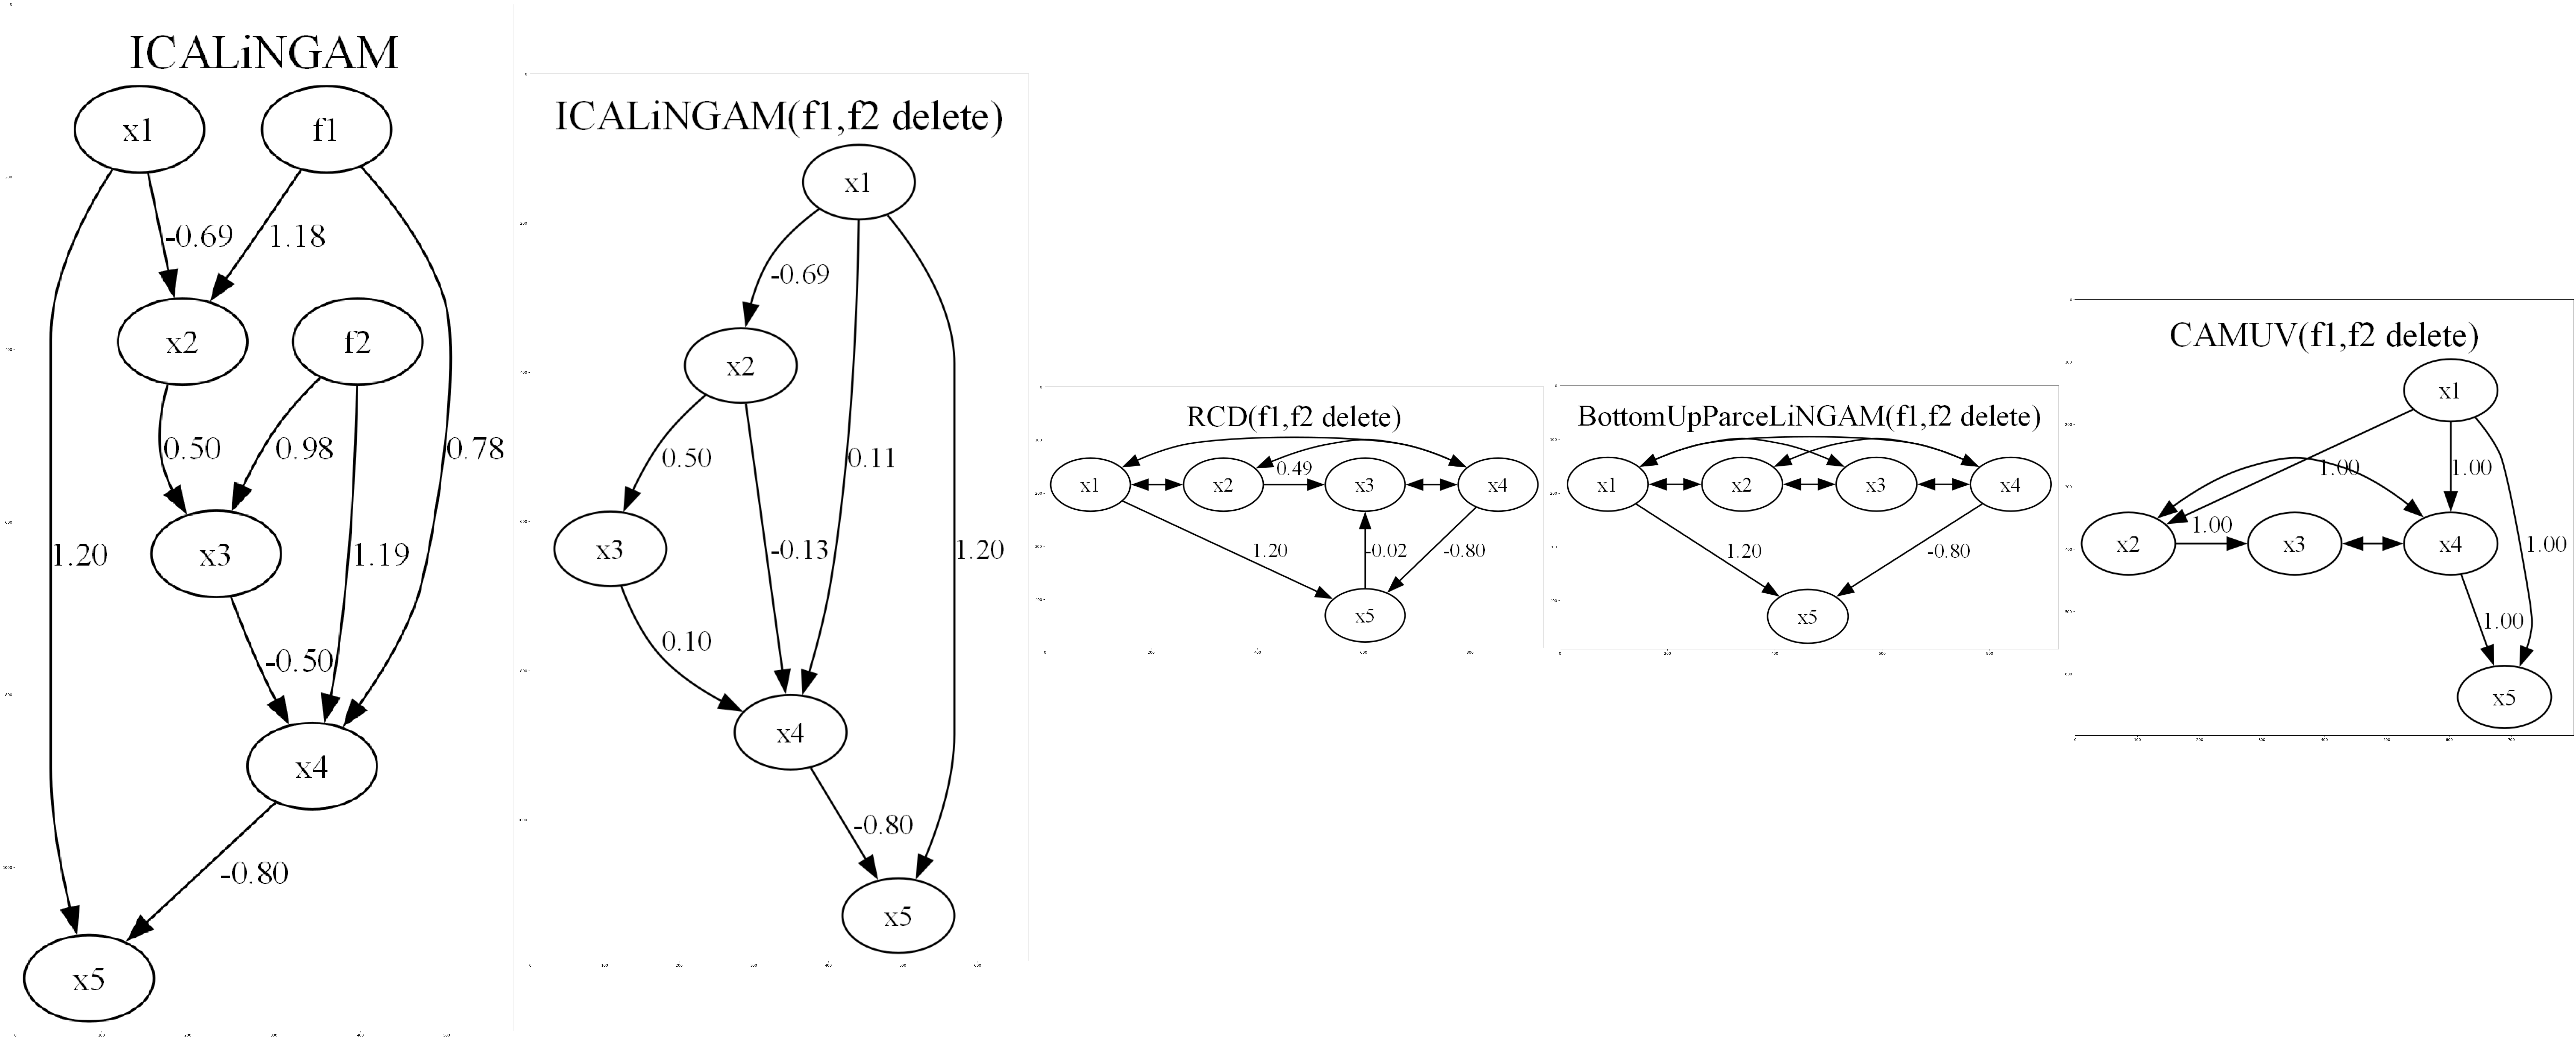

In [11]:
csv1='LiNGAM_latest3'
csv2='nonlinear_LiNGAM_latest3a'
csv3='nonlinear_LiNGAM_latest3b'
csv4='nonlinear_LiNGAM_latest3c'

Causal_discovery_test( csv1 )
Causal_discovery_test( csv2 )
Causal_discovery_test( csv3 )
Causal_discovery_test( csv4 )


ICALiNGAM_nonlinear
0.00022828166644709805
['X1' 'X2' 'X3']


C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


RCD_nonlinear
1.4644548333327596
BottomUpParceLiNGAM_nonlinear
0.8123391266659988
RCD_nonlinear
2.765665085000607
causal order: [2]
causal order: [2, 1]
abpnl_nonlinear
252.46945422999949


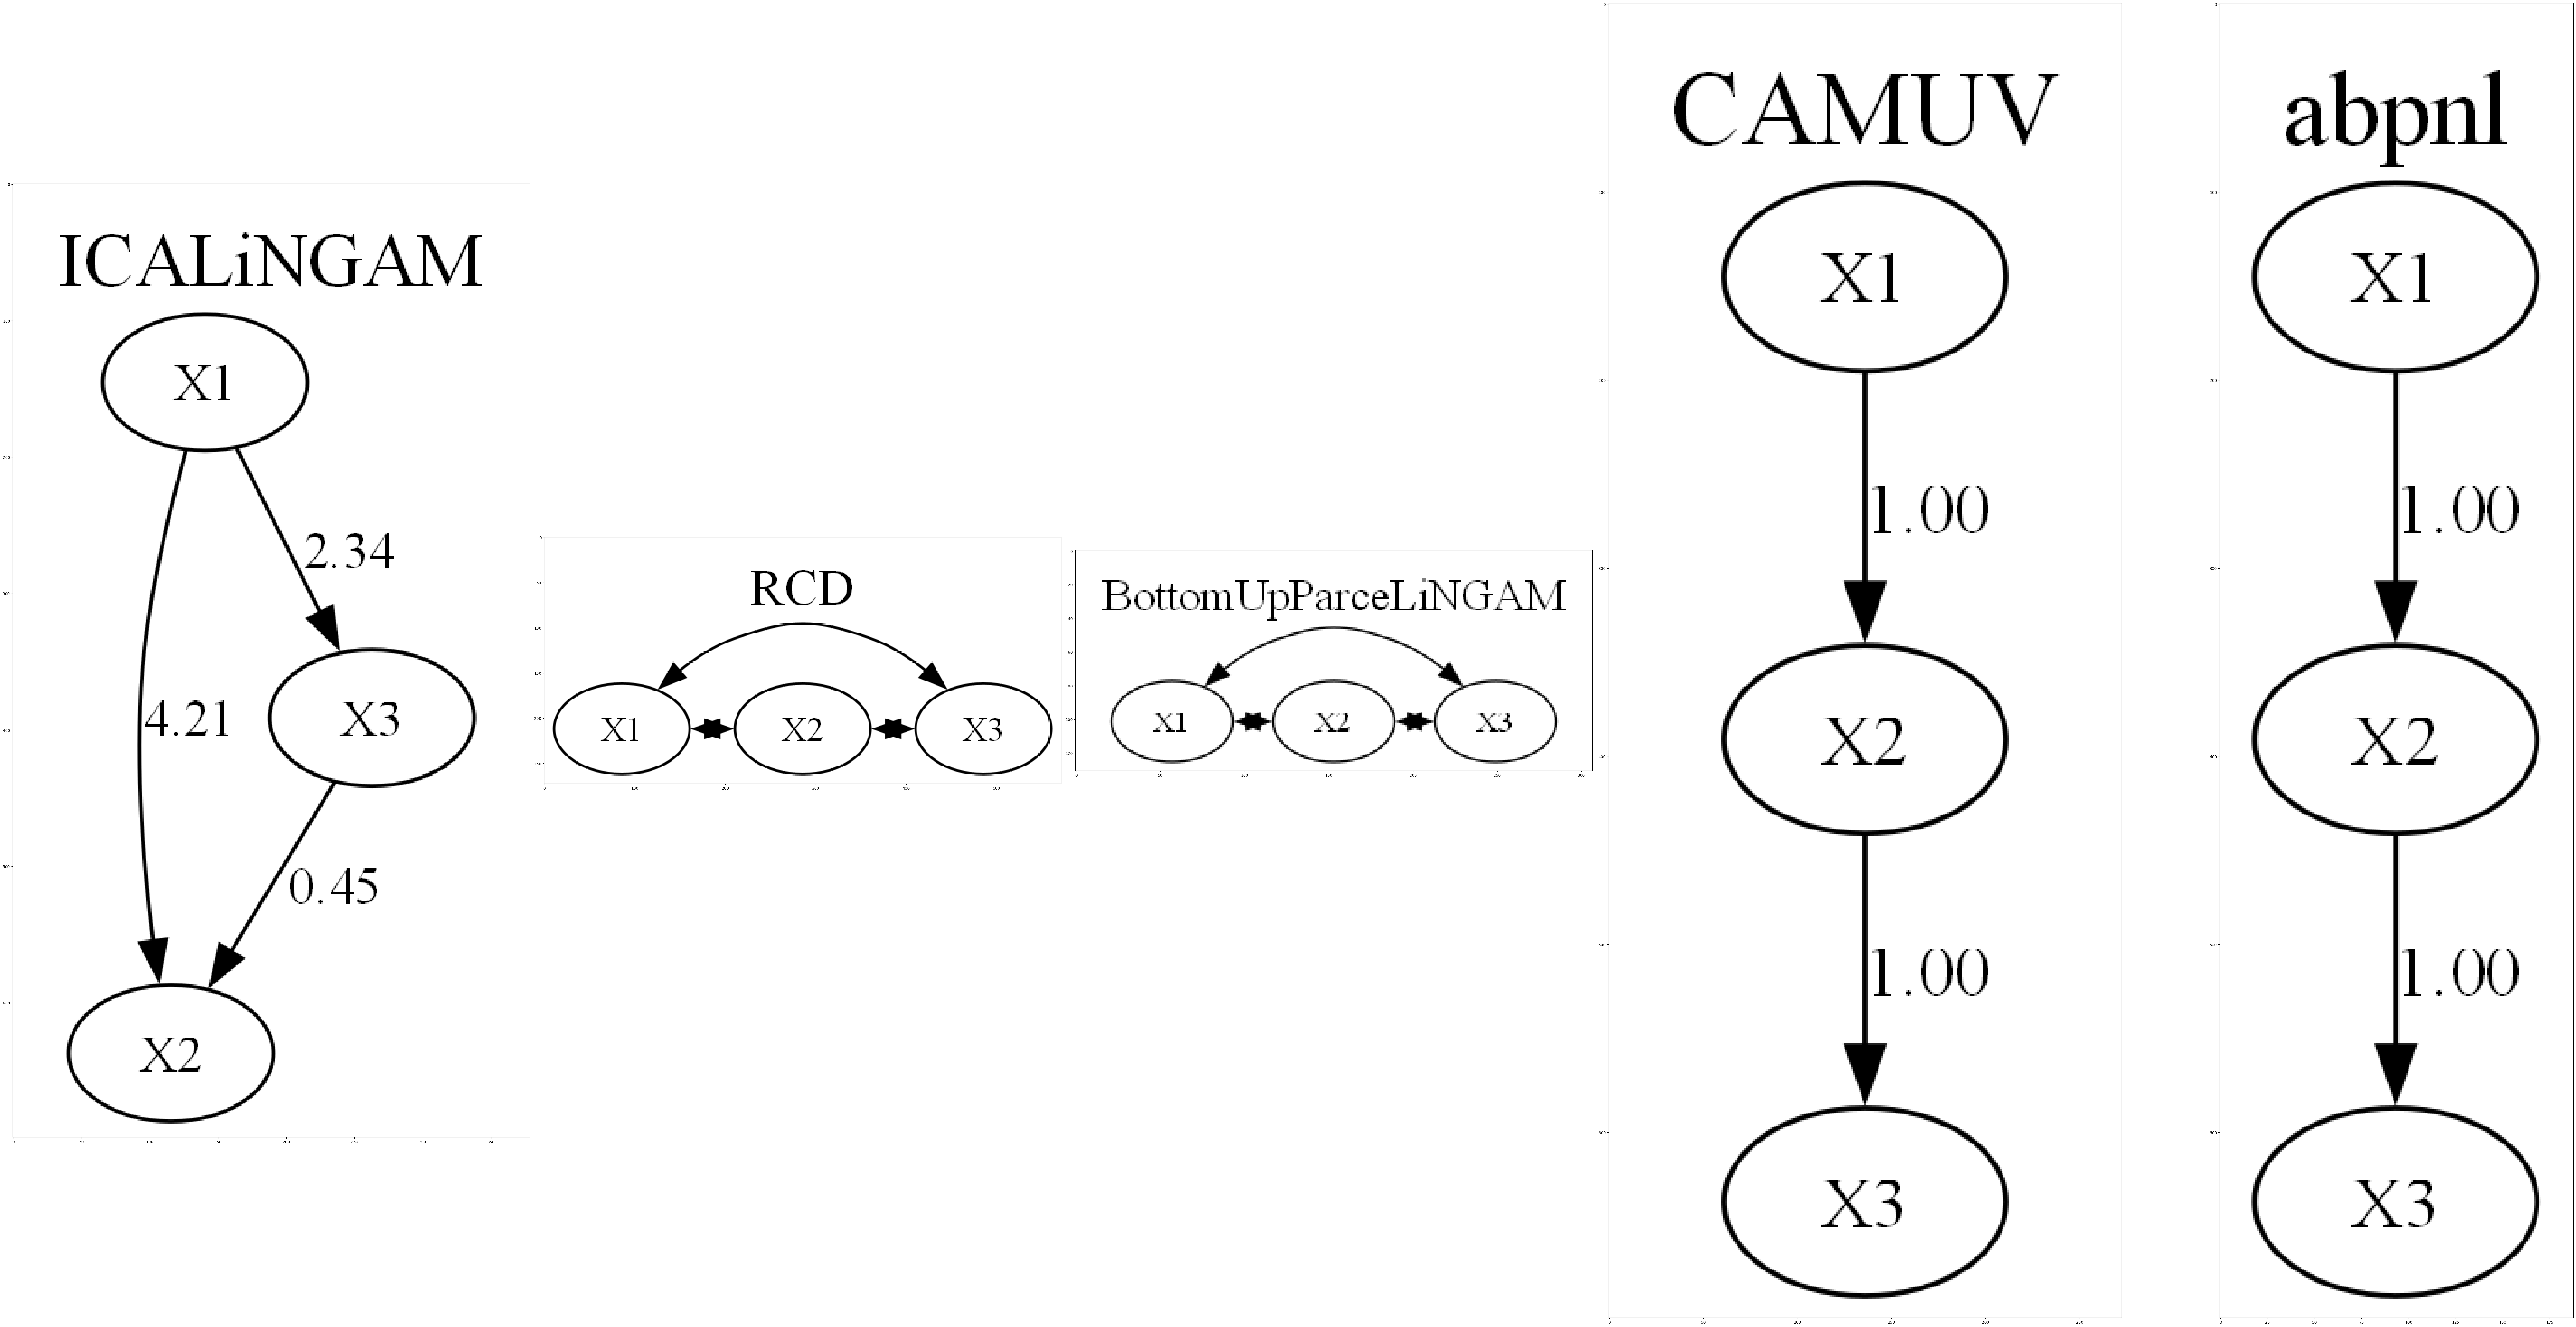

ICALiNGAM_nonlinear2
0.00035827666676292816
['w' 'x' 'y' 'z']


C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


RCD_nonlinear2
0.3864986083334467
BottomUpParceLiNGAM_nonlinear2
1.1572112783343376
RCD_nonlinear2
3.506984338333132
causal order: [2]
causal order: [2, 3]
causal order: [2, 3, 1]
abpnl_nonlinear2
357.5253066383341


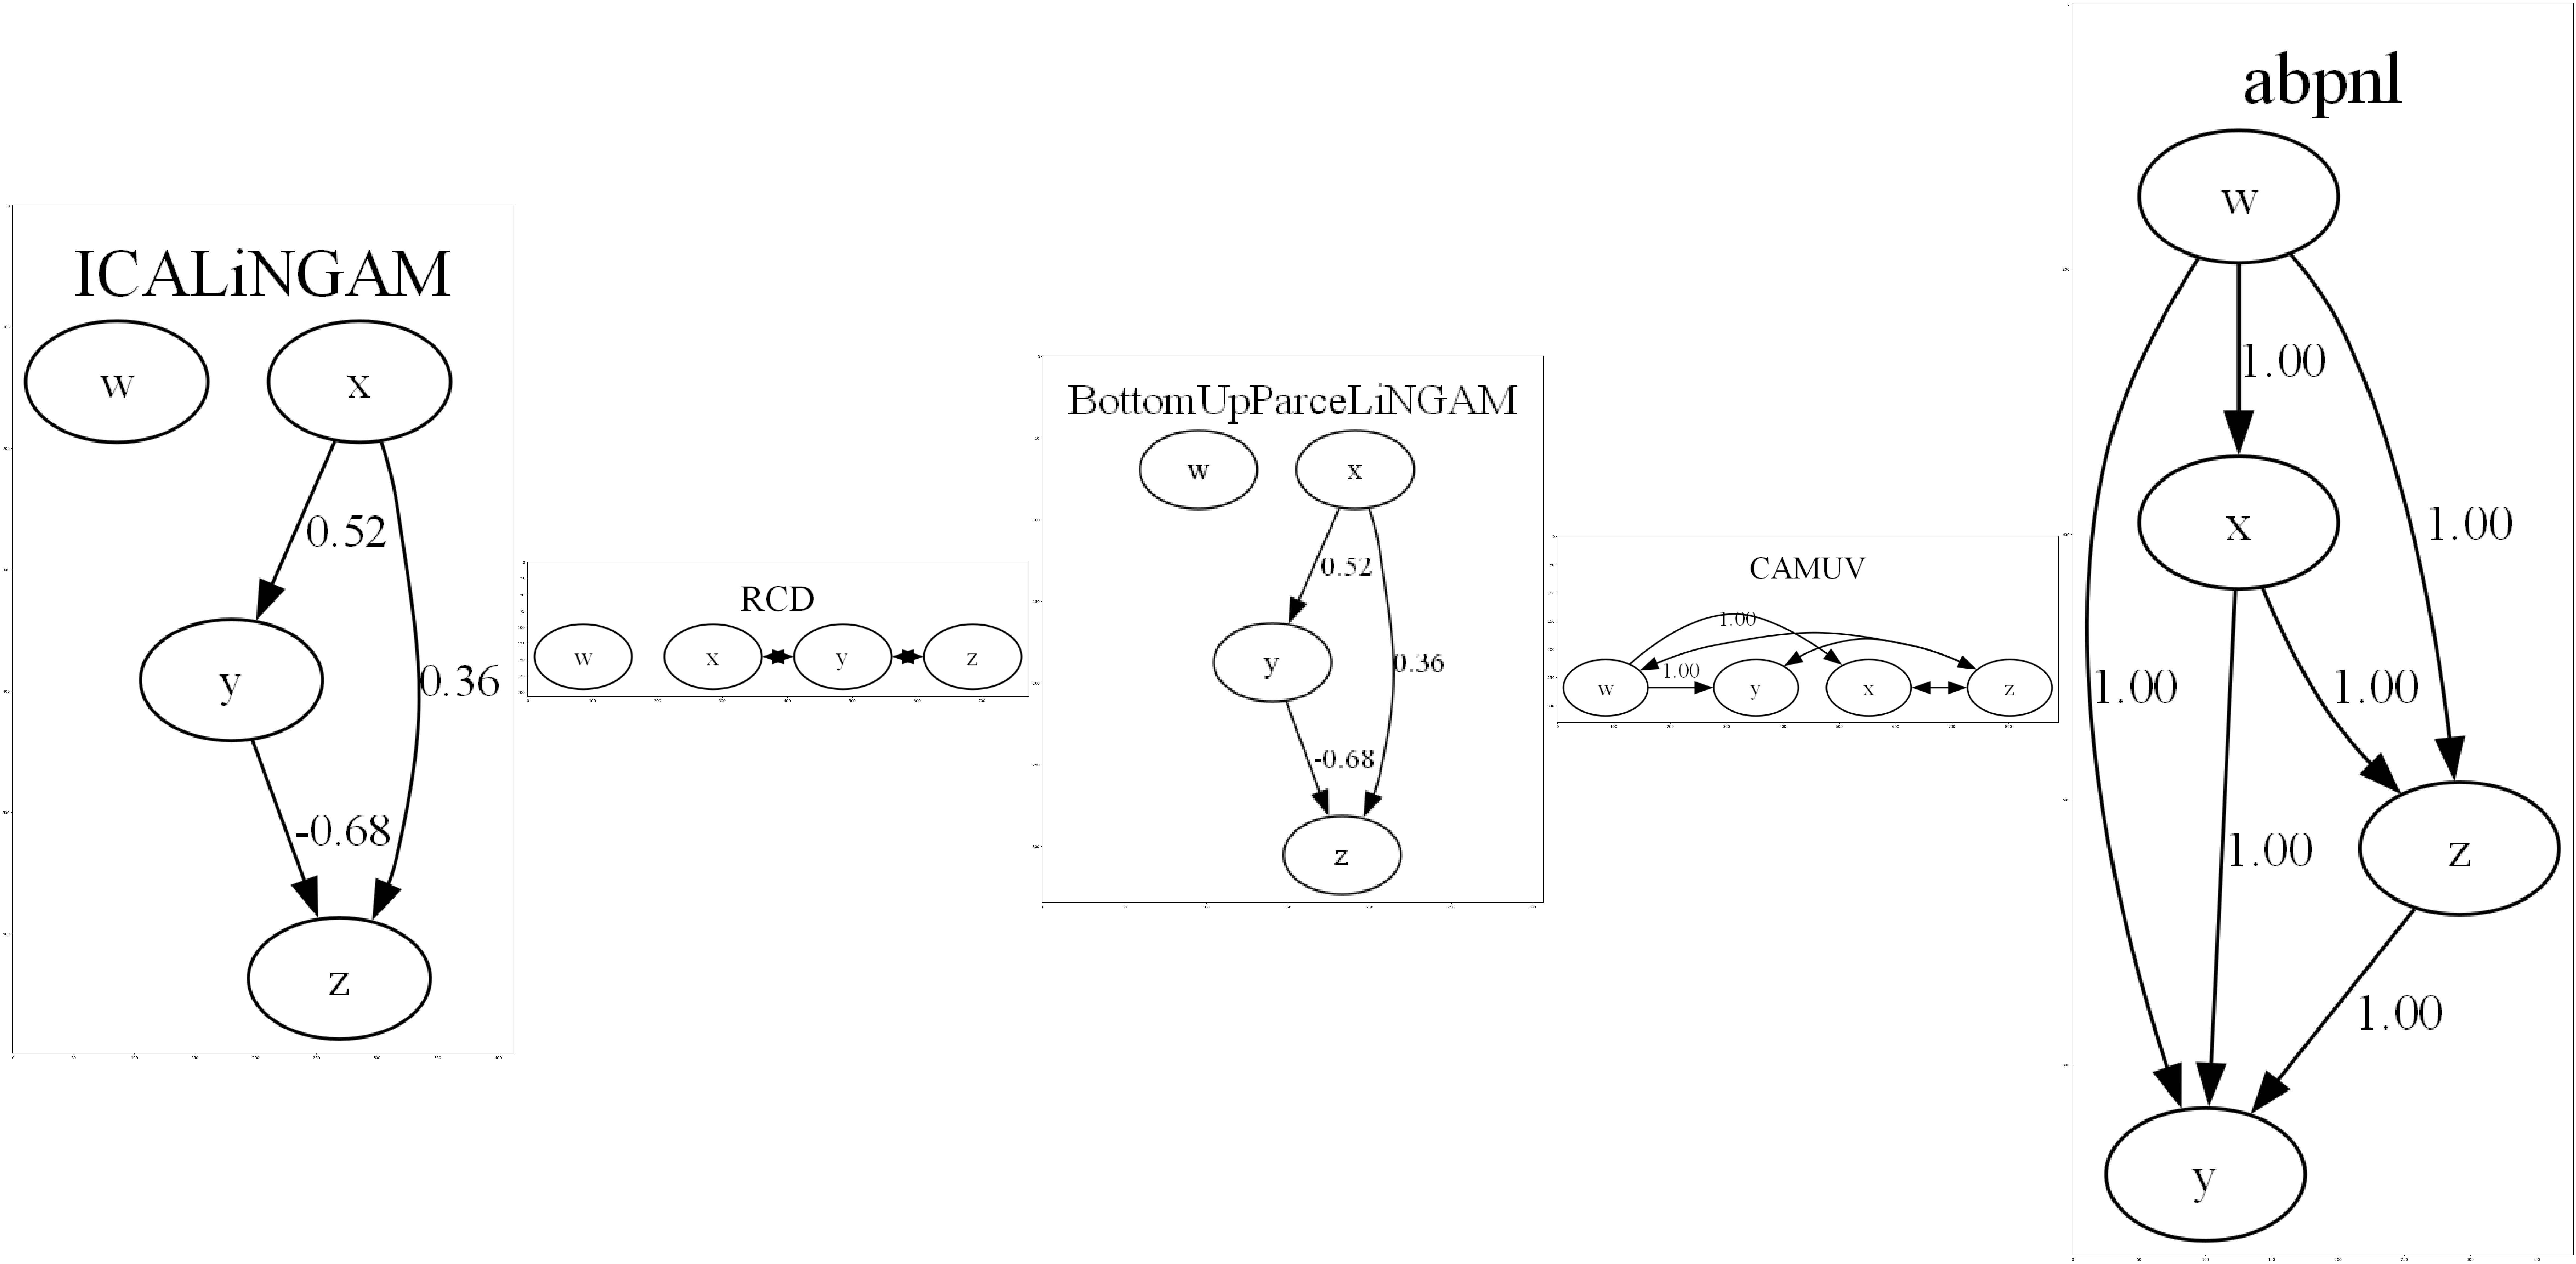

In [12]:
csv1='nonlinear'
csv2='nonlinear2'

Causal_discovery_test2( csv1 )
Causal_discovery_test2( csv2 )

In [2]:
csv1='LiNGAM_latest3'
csv2='nonlinear_LiNGAM_latest3a'
csv3='nonlinear_LiNGAM_latest3b'
csv4='nonlinear_LiNGAM_latest3c'

Causal_discovery_test3( csv1,[] )
Causal_discovery_test3( csv1,['f1','f2'] )
Causal_discovery_test3( csv2,['f1', 'f2'] )
Causal_discovery_test3( csv3,['f1', 'f2'] )
Causal_discovery_test3( csv4,['f1', 'f2'] )


['x1', 'x2', 'x3', 'x4', 'x5', 'f1', 'f2']
causal order: [4]
causal order: [4, 3]
causal order: [4, 3, 2]
causal order: [4, 3, 2, 6]
causal order: [4, 3, 2, 6, 1]
causal order: [4, 3, 2, 6, 1, 5]
abpnl_LiNGAM_latest3
3449.132845401667
['x1', 'x2', 'x3', 'x4', 'x5']
causal order: [4]
causal order: [4, 3]
causal order: [4, 3, 2]
causal order: [4, 3, 2, 1]
abpnl_LiNGAM_latest3
1027.5008919349998
['x1', 'x2', 'x3', 'x4', 'x5']
causal order: [3]
causal order: [3, 1]
causal order: [3, 1, 2]
causal order: [3, 1, 2, 4]
abpnl_nonlinear_LiNGAM_latest3a
1474.4468859050005
['x1', 'x2', 'x3', 'x4', 'x5']
causal order: [3]
causal order: [3, 2]
causal order: [3, 2, 1]
causal order: [3, 2, 1, 0]
abpnl_nonlinear_LiNGAM_latest3b
987.1018566933334
['x1', 'x2', 'x3', 'x4', 'x5']
causal order: [2]
causal order: [2, 4]
causal order: [2, 4, 3]
causal order: [2, 4, 3, 1]
abpnl_nonlinear_LiNGAM_latest3c
1090.470943279999


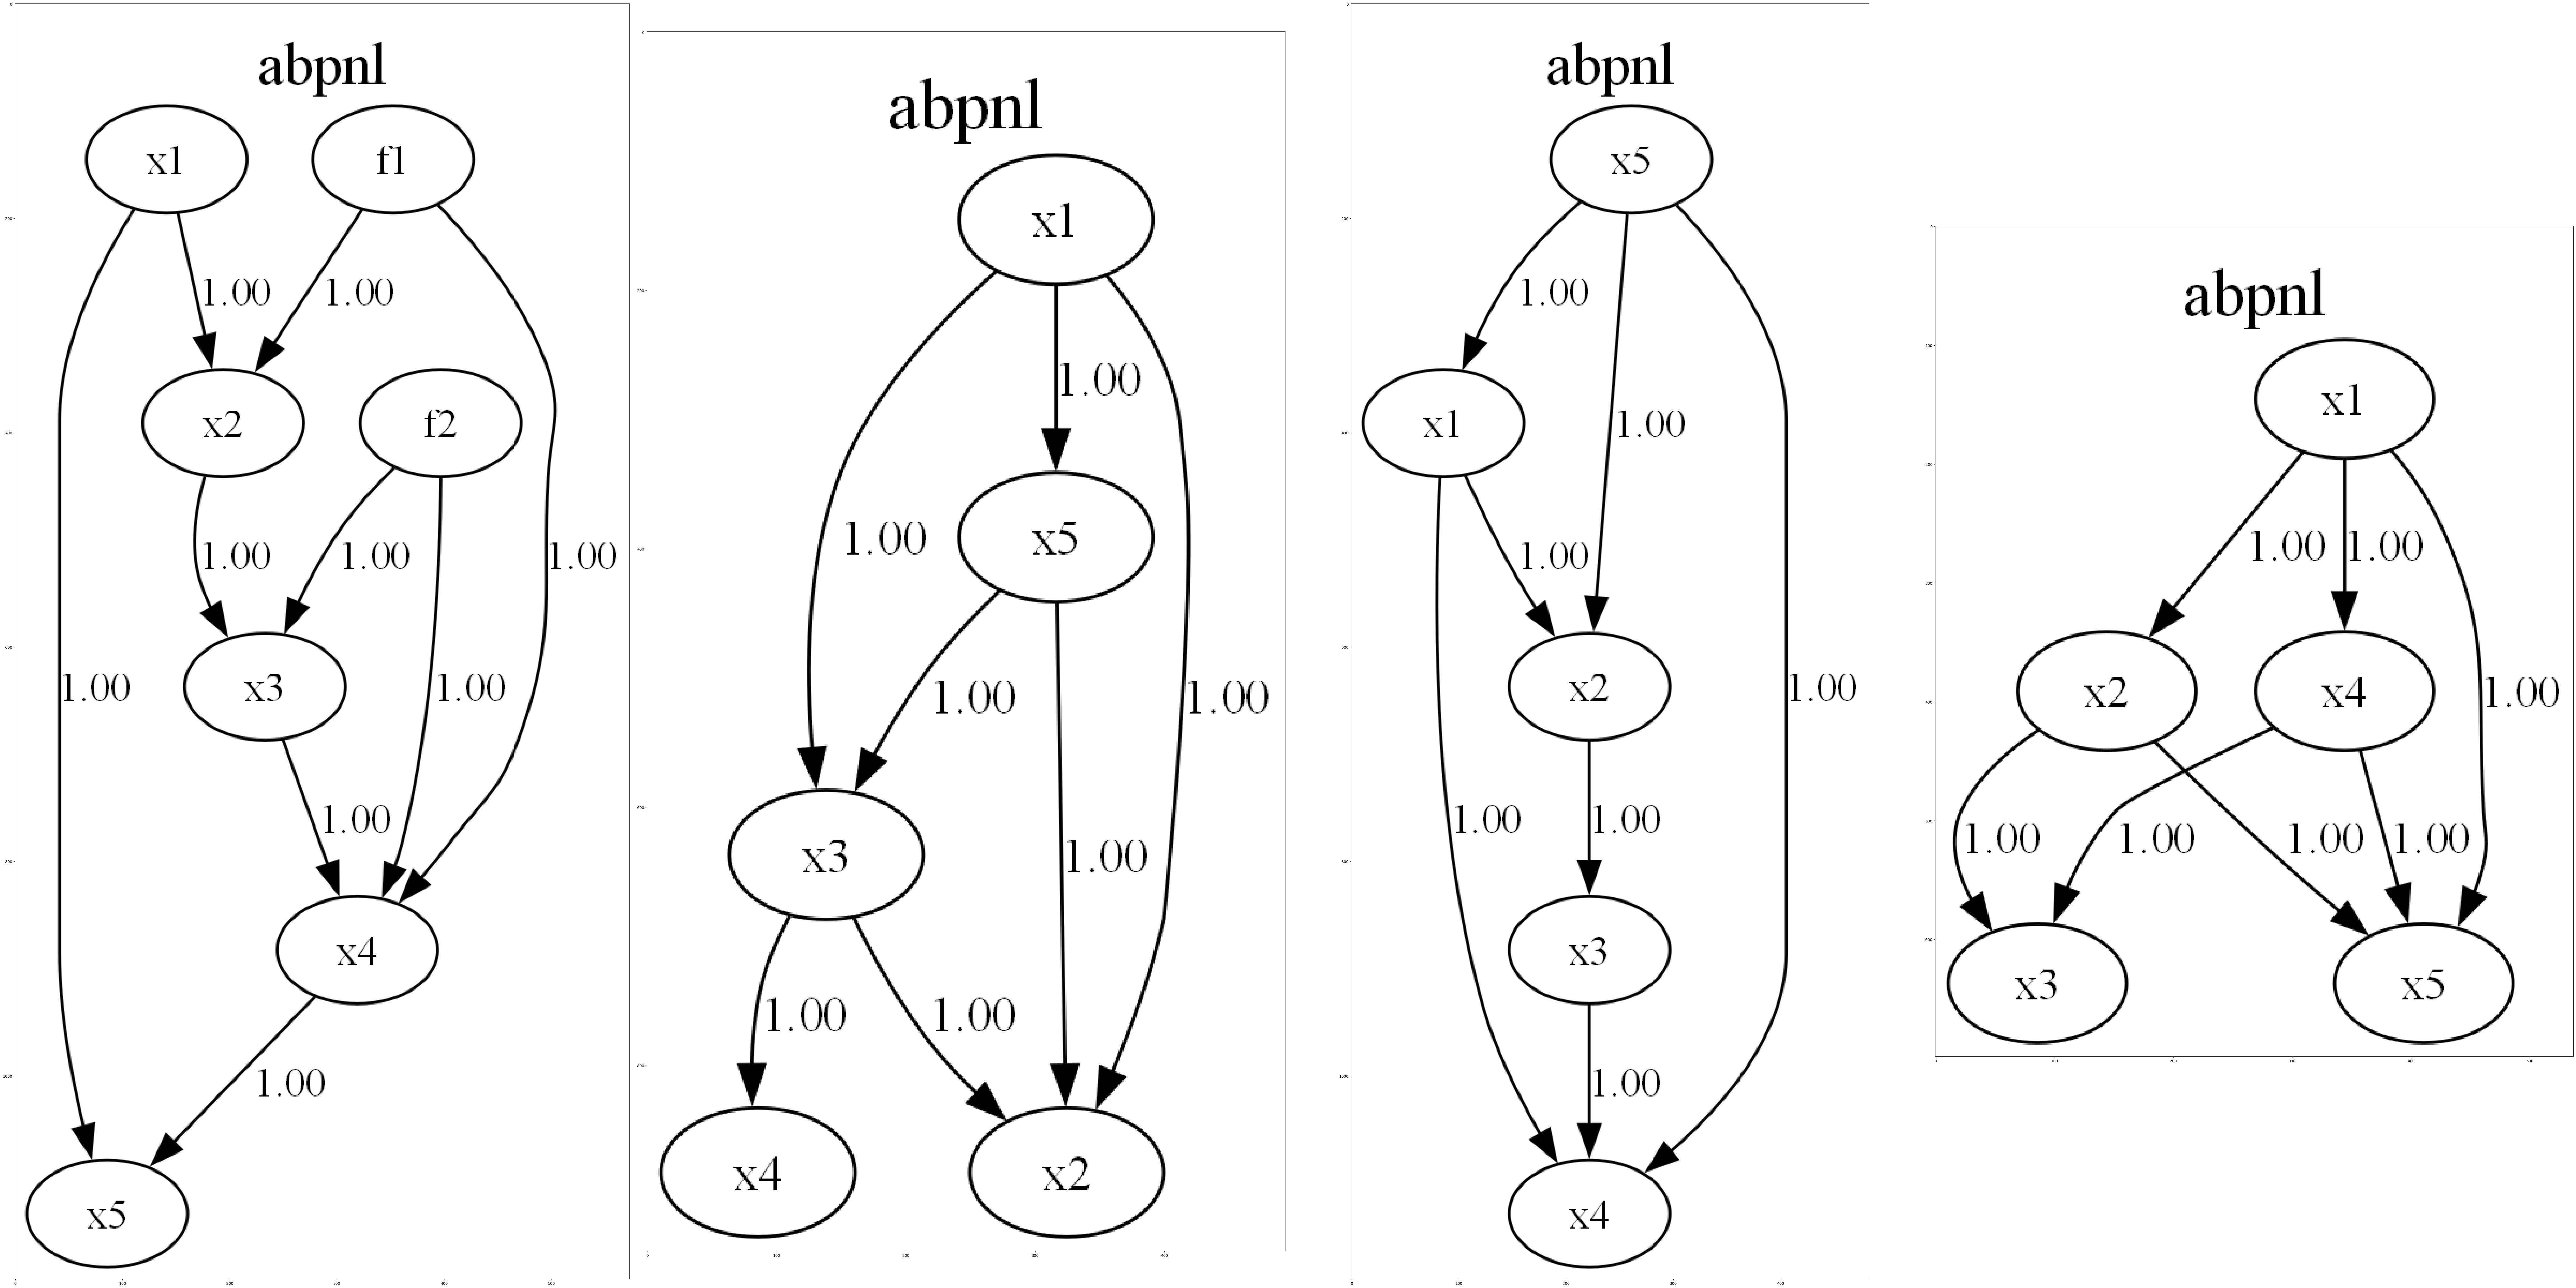

In [3]:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 4, figsize=(12*2*2*2, 6*2*2*2))
    
    ax[0].imshow( plt.imread('abpnl_LiNGAM_latest3.png'))
    ax[1].imshow( plt.imread('abpnl(delete_f1f2)_nonlinear_LiNGAM_latest3a.png'))
    ax[2].imshow( plt.imread('abpnl(delete_f1f2)_nonlinear_LiNGAM_latest3b.png'))
    ax[3].imshow( plt.imread('abpnl(delete_f1f2)_nonlinear_LiNGAM_latest3c.png'))
    fig.tight_layout() 
    plt.savefig('Causal_discovery_abpnl.png', dpi=300)
    plt.tight_layout()
    plt.show()       